## Task1 - Race bias analysis

Goal: Check whether perceived traits differ across race groups
(White, Black, East Asian) using descriptive statistics and one-way ANOVA.

In [2]:
import pandas as pd
import numpy as np

from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "data.csv"
)

df.head()

,Filename,Image #,Gender,Race,Confident,Egotistic,Intelligent,Kind,Responsible,Trustworthy,Aggressive,Caring,Emotional,Friendly,Sociable,Qualified
0,Google_1_Danielle Goble_5_oval.jpg,1,1,1,5.67,3.67,5.60,5.00,5.80,5.33,4.80,4.67,3.67,4.33,4.67,0
1,Google_1_Phillip Owensby_9_oval.jpg,2,0,1,6.53,2.20,6.60,7.00,7.47,6.73,3.13,6.93,5.80,6.73,6.60,1
2,Google_1_Douglas Ziegler_3_oval.jpg,3,1,1,6.07,3.60,6.47,6.47,6.67,6.40,2.40,6.07,5.14,6.67,6.67,0
3,Google_1_Donald Sauls_11_oval.jpg,4,1,2,4.80,4.60,4.47,3.80,4.27,3.87,5.80,3.53,2.80,2.93,3.27,0
4,Google_1_Eric Harman_5_oval.jpg,5,1,6,6.67,5.40,6.33,4.87,5.87,4.67,4.27,4.07,4.80,5.20,5.33,1


In [4]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2222 entries, 0 to 2221
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Filename     2222 non-null   object 
 1   Image #      2222 non-null   int64  
 2   Gender       2222 non-null   int64  
 3   Race         2222 non-null   int64  
 4   Confident    2222 non-null   float64
 5   Egotistic    2222 non-null   float64
 6   Intelligent  2222 non-null   float64
 7   Kind         2222 non-null   float64
 8   Responsible  2222 non-null   float64
 9   Trustworthy  2222 non-null   float64
 10  Aggressive   2222 non-null   float64
 11  Caring       2222 non-null   float64
 12  Emotional    2222 non-null   float64
 13  Friendly     2222 non-null   float64
 14  Sociable     2222 non-null   float64
 15  Qualified    2222 non-null   int64  
dtypes: float64(11), int64(4), object(1)
memory usage: 277.9+ KB


Index(['Filename', 'Image #', 'Gender', 'Race', 'Confident', 'Egotistic',
       'Intelligent', 'Kind', 'Responsible', 'Trustworthy', 'Aggressive',
       'Caring', 'Emotional', 'Friendly', 'Sociable', 'Qualified'],
      dtype='object')

In [5]:
df["Race"].unique()

array([1, 2, 6, 5, 3, 4, 0])

In [6]:

race_col = "Race"

race_groups = [1, 2, 6]  
traits = [
    "Confident", "Egotistic", "Intelligent", "Kind", "Responsible",
    "Trustworthy", "Aggressive", "Caring", "Emotional", "Friendly", "Sociable"
]


df_race = df[df[race_col].isin(race_groups)].copy()

# Drop missing values
df_race = df_race.dropna(subset=[race_col] + traits)

# Check result
df_race[race_col].value_counts()

Race
1    1836
2     220
6      24
Name: count, dtype: int64

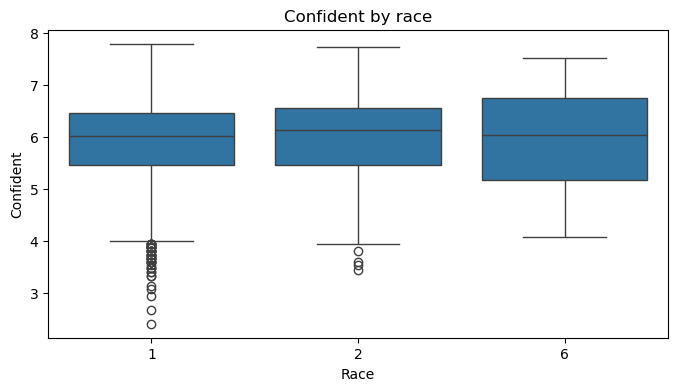

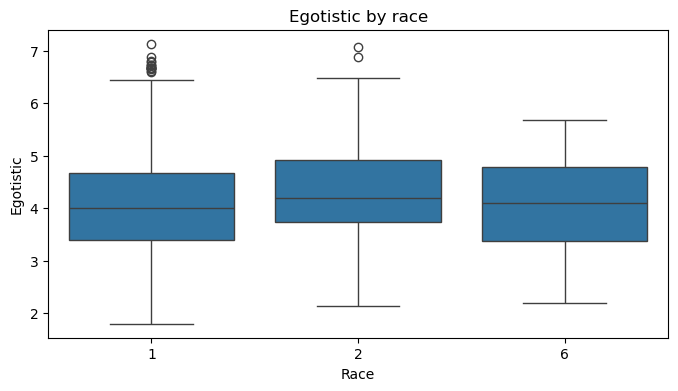

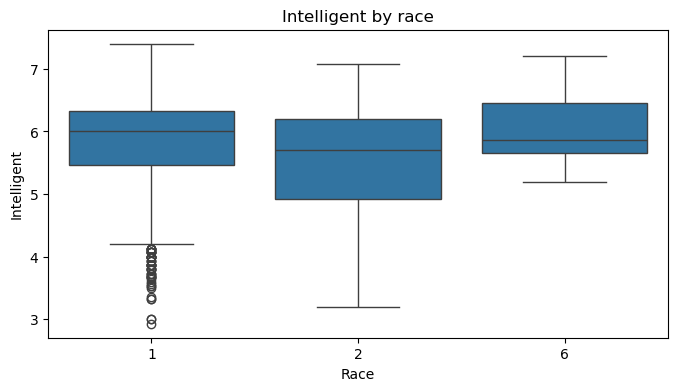

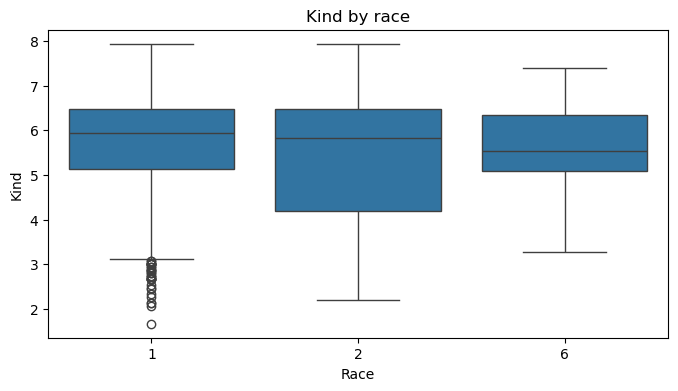

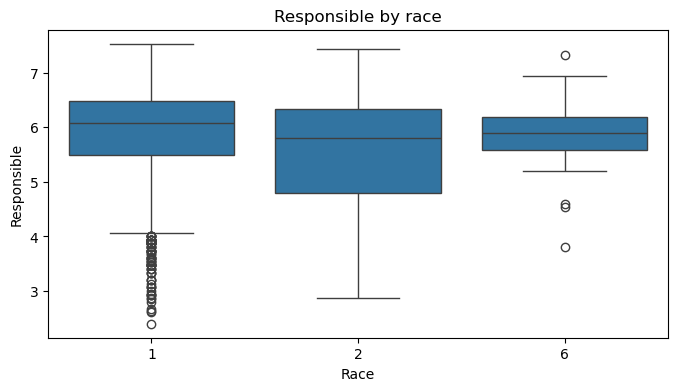

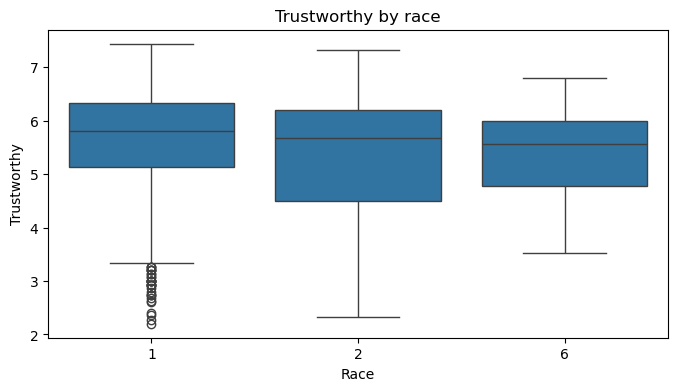

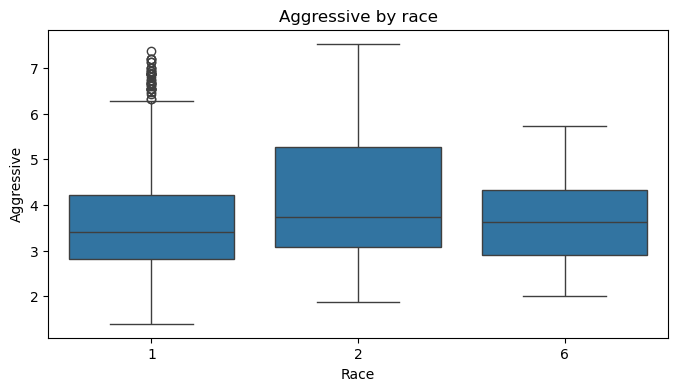

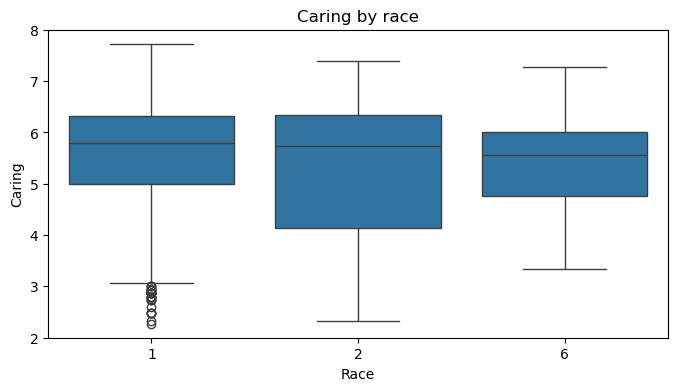

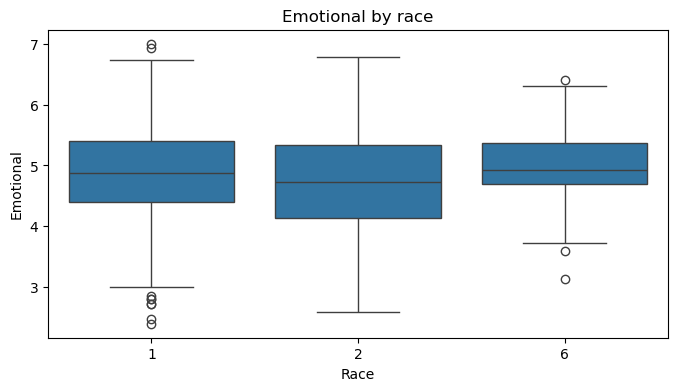

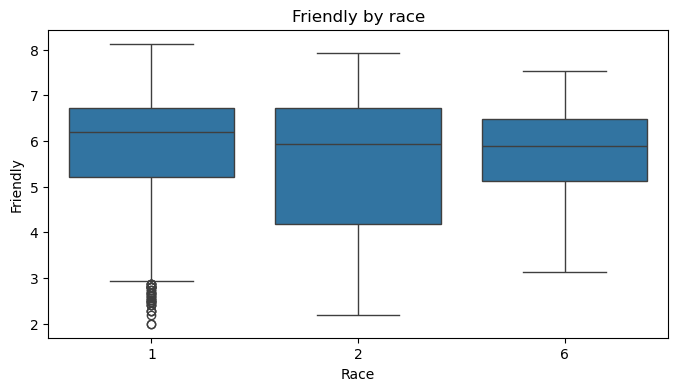

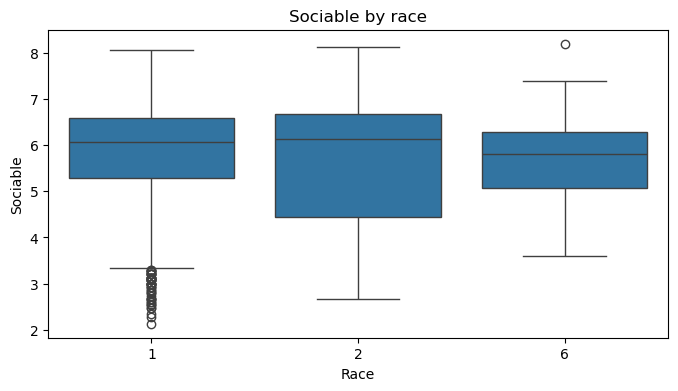

In [7]:
for trait in traits:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_race, x=race_col, y=trait, order=race_groups)
    plt.title(f"{trait} by race")
    plt.show()

In [8]:
anova_results = []

for trait in traits:
    group_data = [df_race[df_race[race_col] == g][trait] for g in race_groups]
    f_stat, p_val = stats.f_oneway(*group_data)
    
    anova_results.append({
        "trait": trait,
        "F-statistic": f_stat,
        "p-value": p_val
    })

anova_df = pd.DataFrame(anova_results).sort_values("p-value")
display(anova_df)

,trait,F-statistic,p-value
2,Intelligent,21.852255,4.056537e-10
4,Responsible,20.026616,2.428567e-09
6,Aggressive,19.088049,6.101409e-09
5,Trustworthy,10.777048,2.206513e-05
9,Friendly,9.056086,1.213504e-04
3,Kind,8.213632,2.798321e-04
1,Egotistic,7.827747,4.103938e-04
7,Caring,7.004204,9.296622e-04
8,Emotional,3.879304,2.081510e-02
10,Sociable,3.694352,2.502710e-02


In [9]:
alpha = 0.05
significant_traits = anova_df[anova_df["p-value"] < alpha]
display(significant_traits)

,trait,F-statistic,p-value
2,Intelligent,21.852255,4.056537e-10
4,Responsible,20.026616,2.428567e-09
6,Aggressive,19.088049,6.101409e-09
5,Trustworthy,10.777048,2.206513e-05
9,Friendly,9.056086,1.213504e-04
3,Kind,8.213632,2.798321e-04
1,Egotistic,7.827747,4.103938e-04
7,Caring,7.004204,9.296622e-04
8,Emotional,3.879304,2.081510e-02
10,Sociable,3.694352,2.502710e-02


In [11]:
df_race.groupby("Race")[traits].mean()

,Confident,Egotistic,Intelligent,Kind,Responsible,Trustworthy,Aggressive,Caring,Emotional,Friendly,Sociable
Race,,,,,,,,,,,
1,5.925109,4.057195,5.863676,5.715496,5.905479,5.645065,3.636961,5.580169,4.869951,5.867516,5.851906
2,5.967909,4.322545,5.528636,5.404500,5.514227,5.346682,4.128409,5.305455,4.732318,5.498636,5.647455
6,5.939167,4.092917,6.049583,5.619167,5.849167,5.413333,3.678750,5.368750,4.940000,5.730417,5.641250


## Task2- Gender Bias Analysis

In [13]:
df["Gender"].value_counts()
df["Gender"].unique()
df.groupby("Gender")["Aggressive"].mean()


Gender
0    3.127545
1    4.110788
Name: Aggressive, dtype: float64

In [14]:
gender_map = {
    1: "Male",
    0: "Female"
}

df["GenderLabel"] = df["Gender"].map(gender_map)
df["GenderLabel"].value_counts()

GenderLabel
Male      1269
Female     953
Name: count, dtype: int64

In [15]:
traits = [
    "Confident", "Egotistic", "Intelligent", "Kind", "Responsible",
    "Trustworthy", "Aggressive", "Caring", "Emotional", "Friendly", "Sociable"
]

In [16]:
from scipy.stats import ttest_ind

male = df[df["GenderLabel"] == "Male"]
female = df[df["GenderLabel"] == "Female"]

results = []

for trait in traits:
    t_stat, p_val = ttest_ind(
        male[trait],
        female[trait],
        equal_var=False
    )
    
    results.append({
        "Trait": trait,
        "t-statistic": t_stat,
        "p-value": p_val
    })

t_test_df = pd.DataFrame(results).sort_values("p-value")
t_test_df

,Trait,t-statistic,p-value
8,Emotional,-30.599504,1.410518e-171
7,Caring,-23.882151,2.199732e-112
6,Aggressive,23.565660,9.728138e-110
1,Egotistic,23.061066,2.577732e-105
3,Kind,-21.121340,2.202614e-90
5,Trustworthy,-19.558382,1.018767e-78
9,Friendly,-18.220183,3.093717e-69
10,Sociable,-17.914342,3.879471e-67
4,Responsible,-12.953607,4.799703e-37
2,Intelligent,-6.428341,1.574465e-10


## Task 4 - Plot histograms for the most significant biases

In [19]:
df["GenderLabel"]  

0         Male
1       Female
2         Male
3         Male
4         Male
         ...  
2217    Female
2218    Female
2219      Male
2220    Female
2221    Female
Name: GenderLabel, Length: 2222, dtype: object

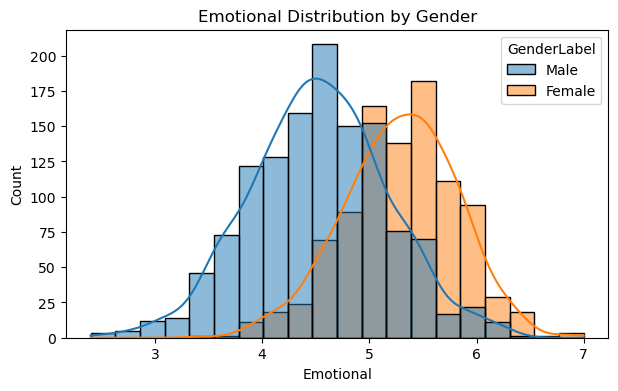

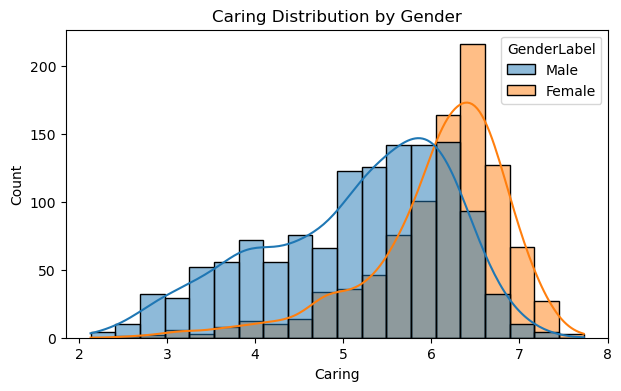

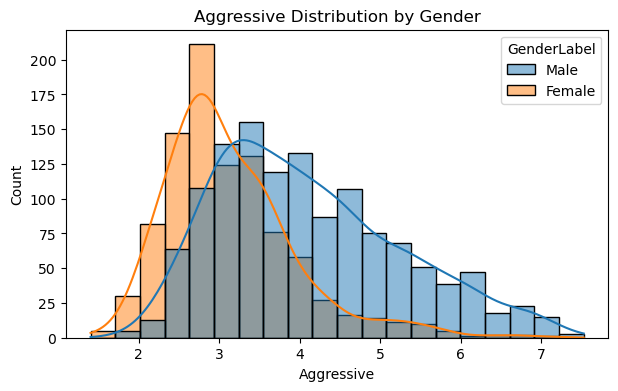

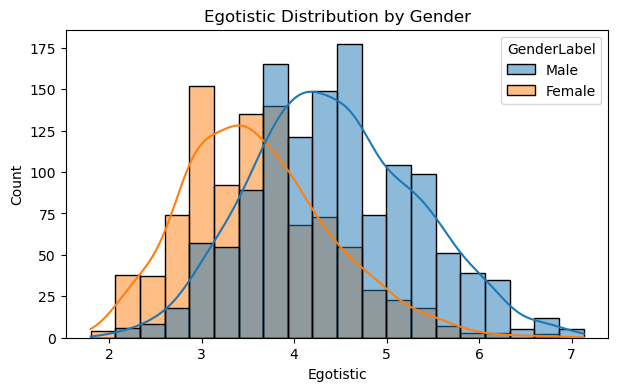

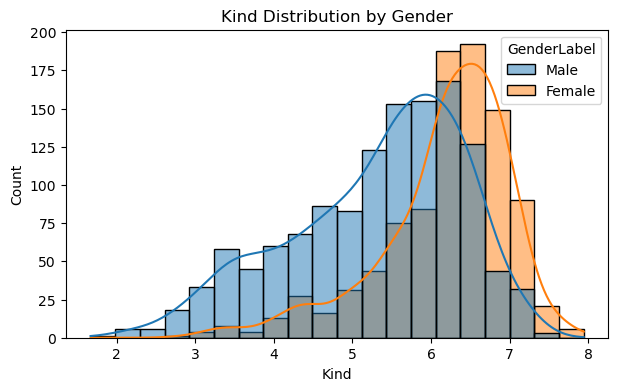

In [21]:
for trait in traits_top5:
    plt.figure(figsize=(7,4))
    
    sns.histplot(data=df, x=trait, hue="GenderLabel", bins=20, kde=True)
    
    plt.title(f"{trait} Distribution by Gender")
    plt.show()

## Task 5 - Four-fifths rule

In [23]:
gender_selection = df.groupby("GenderLabel")["Qualified"].mean()
gender_selection

GenderLabel
Female    0.118573
Male      0.208826
Name: Qualified, dtype: float64

In [25]:
# use RaceLabel from earlier
race_selection = df.groupby("Race")["Qualified"].mean()
race_selection

Race
0    0.000000
1    0.183007
2    0.122727
3    0.174603
4    0.000000
5    0.027778
6    0.083333
Name: Qualified, dtype: float64

In [26]:
max_rate = gender_selection.max()
threshold = 0.8 * max_rate

print("Max rate:", max_rate)
print("Threshold (80%):", threshold)

gender_selection

Max rate: 0.20882584712371946
Threshold (80%): 0.1670606776989756


GenderLabel
Female    0.118573
Male      0.208826
Name: Qualified, dtype: float64

In [27]:
gender_selection < threshold

GenderLabel
Female     True
Male      False
Name: Qualified, dtype: bool

In [28]:
max_rate_race = race_selection.max()
threshold_race = 0.8 * max_rate_race

race_selection < threshold_race

Race
0     True
1    False
2     True
3    False
4     True
5     True
6     True
Name: Qualified, dtype: bool